## Import các thư viện cần thiết

In [1]:
import pandas as pd
import re
import html
import unicodedata
import string

##Đọc dữ liệu

In [2]:
DATA_PATH = "/content/train-00000-of-00001.parquet"
df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(184349, 2)


,vi_context,label
0,Cocksucker trước khi bạn đi_tiểu vào công_việc...,NEG
1,"Này , nói_chuyện gì là một nhóm độc_quyền của ...",NEG
2,Tạm_biệt không nhìn đến hoặc nghĩ về việc quay...,NEG
3,Lời chào của đồng lãnh đồng_thời tổng lãnh thi...,NEG
4,Mẹ_kiếp người mẹ bẩn_thỉu của bạn trong ass khô,NEG


##Kiểm tra schema

In [3]:
print(df.info())
print(df.columns)
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184349 entries, 0 to 184348
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   vi_context  184349 non-null  object
 1   label       184349 non-null  object
dtypes: object(2)
memory usage: 2.8+ MB
None
Index(['vi_context', 'label'], dtype='object')
label
NEG    92271
POS    92078
Name: count, dtype: int64


##Rename columns + map label

In [4]:
df = df.rename(columns={
    "vi_context": "text",
    "label": "original_label"
})

label_map = {
    "POS": 0,  # non-toxic
    "NEG": 1   # toxic
}

df["label"] = df["original_label"].map(label_map)

df.head()

,text,original_label,label
0,Cocksucker trước khi bạn đi_tiểu vào công_việc...,NEG,1
1,"Này , nói_chuyện gì là một nhóm độc_quyền của ...",NEG,1
2,Tạm_biệt không nhìn đến hoặc nghĩ về việc quay...,NEG,1
3,Lời chào của đồng lãnh đồng_thời tổng lãnh thi...,NEG,1
4,Mẹ_kiếp người mẹ bẩn_thỉu của bạn trong ass khô,NEG,1


##Check missing values

In [5]:
print(df.isnull().sum())

df = df.dropna(subset=["text", "original_label", "label"])

df["text"] = df["text"].astype(str)
df = df[df["text"].str.strip() != ""]

print(df.shape)

text              0
original_label    0
label             0
dtype: int64
(184349, 3)


##làm sạch text tiếng Việt

In [6]:
# Chuẩn hóa Unicode tiếng Việt
def normalize_unicode(text):
    return unicodedata.normalize("NFC", text)

# Xóa khoảng trắng thừa
def clean_whitespace(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Xóa dấu câu nhưng giữ lại dấu "_"
# Vì dataset đã word segmentation: "quan_hệ_tình_dục", "cuộc_sống", "có_thể"
# Với TF-IDF + ML truyền thống, giữ "_" giúp cụm từ tiếng Việt thành 1 token có nghĩa
def remove_punctuation_keep_underscore(text):
    punctuation = string.punctuation.replace("_", "")
    translator = str.maketrans("", "", punctuation)
    return text.translate(translator)

# Rút ký tự lặp liên tiếp về 1 ký tự
# Ví dụ: "nguuuuuu" -> "ngu", "đẹpppp" -> "đẹp"
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{1,}", r"\1", text)

# Rút từ lặp liên tiếp về 1 lần
# Ví dụ: "ngu ngu ngu" -> "ngu"
def normalize_repeated_words(text):
    return re.sub(r"\b(\w+)(\s+\1\b)+", r"\1", text)

# Hàm xử lý chính cho từng comment
def preprocess_text(text):
    text = str(text)
    text = html.unescape(text)
    text = normalize_unicode(text)
    text = text.lower()
    text = normalize_repeated_chars(text)
    text = remove_punctuation_keep_underscore(text)
    text = clean_whitespace(text)
    text = normalize_repeated_words(text)
    return text

## Áp dụng preprocessing

In [7]:
df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text", "original_label", "label"]].head(10)

,text,clean_text,original_label,label
0,Cocksucker trước khi bạn đi_tiểu vào công_việc...,cocksucker trước khi bạn đi_tiểu vào công_việc...,NEG,1
1,"Này , nói_chuyện gì là một nhóm độc_quyền của ...",này nói_chuyện gì là một nhóm độc_quyền của mộ...,NEG,1
2,Tạm_biệt không nhìn đến hoặc nghĩ về việc quay...,tạm_biệt không nhìn đến hoặc nghĩ về việc quay...,NEG,1
3,Lời chào của đồng lãnh đồng_thời tổng lãnh thi...,lời chào của đồng lãnh đồng_thời tổng lãnh thi...,NEG,1
4,Mẹ_kiếp người mẹ bẩn_thỉu của bạn trong ass khô,mẹ_kiếp người mẹ bẩn_thỉu của bạn trong as khô,NEG,1
5,"Tôi xin_lỗi , tôi xin_lỗi , tôi đã làm_phiền v...",tôi xin_lỗi tôi xin_lỗi tôi đã làm_phiền với t...,NEG,1
6,Nhận fucked lên nhận được fuckeed up có một th...,nhận fucked lên nhận được fucked up có một thứ...,NEG,1
7,"Hoà_bình ngu_ngốc , ngừng xoá lỗ_đít của tôi ,...",hoà_bình ngu_ngốc ngừng xoá lỗ_đít của tôi hãy...,NEG,1
8,Tony_Sidaway rõ_ràng là một fistfuckee anh ấy ...,tony_sidaway rõ_ràng là một fistfucke anh ấy y...,NEG,1
9,Các trang ban nhạc của tôi xoá bạn nghĩ rằng t...,các trang ban nhạc của tôi xoá bạn nghĩ rằng t...,NEG,1


##Tạo feature độ dài text

In [8]:
# Số ký tự trong comment
df["char_len"] = df["clean_text"].str.len()

# Số từ trong comment
df["word_len"] = df["clean_text"].str.split().apply(len)

df[["clean_text", "char_len", "word_len"]].head()

,clean_text,char_len,word_len
0,cocksucker trước khi bạn đi_tiểu vào công_việc...,54,9
1,này nói_chuyện gì là một nhóm độc_quyền của mộ...,266,43
2,tạm_biệt không nhìn đến hoặc nghĩ về việc quay...,56,11
3,lời chào của đồng lãnh đồng_thời tổng lãnh thi...,525,95
4,mẹ_kiếp người mẹ bẩn_thỉu của bạn trong as khô,46,9


##Lọc comment không hợp lệ

In [9]:
before = len(df)

# Loại comment rỗng hoặc quá ngắn
df = df[df["clean_text"].str.strip() != ""]
df = df[df["char_len"] >= 2]
df = df[df["word_len"] >= 1]

after = len(df)

print("Removed invalid rows:", before - after)
print("Remaining rows:", after)

Removed invalid rows: 27
Remaining rows: 184322


## Loại bỏ các hàng trùng lặp

In [10]:
before = len(df)

# Xóa dòng trùng cả text đã xử lý và label
df = df.drop_duplicates(subset=["clean_text", "label"])

after = len(df)

print("Removed duplicate rows:", before - after)
print("Remaining rows:", after)

Removed duplicate rows: 13164
Remaining rows: 171158


## Xử lý các văn bản có nhãn mâu thuẫn

In [11]:
# Tìm các clean_text có nhiều hơn 1 label
conflict_texts = (
    df.groupby("clean_text")["label"]
    .nunique()
    .reset_index()
)

conflict_texts = conflict_texts[conflict_texts["label"] > 1]["clean_text"]

print("Number of conflict texts:", len(conflict_texts))

before = len(df)

# Xóa các text bị gán nhiều nhãn khác nhau
df = df[~df["clean_text"].isin(conflict_texts)]

after = len(df)

print("Removed conflict rows:", before - after)
print("Remaining rows:", after)

Number of conflict texts: 76
Removed conflict rows: 152
Remaining rows: 171006


## Kiểm tra phân bố label


In [12]:
print("Label counts:")
print(df["label"].value_counts())

print("\nLabel ratio:")
print(df["label"].value_counts(normalize=True) * 100)

Label counts:
label
1    87569
0    83437
Name: count, dtype: int64

Label ratio:
label
1    51.208145
0    48.791855
Name: proportion, dtype: float64


##Chia train / validation / test

In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (136804, 6)
Validation: (17101, 6)
Test: (17101, 6)


## Chọn các cột đầu ra

In [14]:
output_cols = [
    "text",
    "clean_text",
    "label",
    "original_label",
    "char_len",
    "word_len"
]

train_df = train_df[output_cols]
val_df = val_df[output_cols]
test_df = test_df[output_cols]

train_df.head()

,text,clean_text,label,original_label,char_len,word_len
109037,Hàng tấn tên thành_viên ở đây bao_gồm riêng,hàng tấn tên thành_viên ở đây bao_gồm riêng,0,POS,43,8
108567,Xin đừng là người kiểm_duyệt mong_muốn,xin đừng là người kiểm_duyệt mong_muốn,0,POS,38,6
80933,Rt marshalltaylor _ bạn có mọi_rợ da đens và t...,rt marshaltaylor _ bạn có mọi_rợ da đens và tô...,1,NEG,62,14
29893,Đã đi đến một bộ phim này của bộ phim này và đ...,đã đi đến một bộ phim này của bộ phim này và đ...,1,NEG,741,145
121044,Preston_Sturgis_The_Power and the Glory đã khô...,preston_sturgis_the_power and the glory đã khô...,0,POS,3700,646


## Lưu file clean

In [15]:
train_df.to_csv("train_clean.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("val_clean.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("test_clean.csv", index=False, encoding="utf-8-sig")

##tổng quan về tập dữ liệu

In [16]:
report = {
    "final_rows": int(len(df)),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "label_distribution": df["label"].value_counts().to_dict(),
    "label_ratio_percent": (df["label"].value_counts(normalize=True) * 100).to_dict(),
    "avg_char_len": float(df["char_len"].mean()),
    "avg_word_len": float(df["word_len"].mean()),
    "max_char_len": int(df["char_len"].max()),
    "max_word_len": int(df["word_len"].max()),
    "min_char_len": int(df["char_len"].min()),
    "min_word_len": int(df["word_len"].min())
}

report

{'final_rows': 171006,
 'train_rows': 136804,
 'val_rows': 17101,
 'test_rows': 17101,
 'label_distribution': {1: 87569, 0: 83437},
 'label_ratio_percent': {1: 51.20814474345929, 0: 48.79185525654071},
 'avg_char_len': 561.0069178859221,
 'avg_word_len': 102.09593230646878,
 'max_char_len': 11441,
 'max_word_len': 2158,
 'min_char_len': 2,
 'min_word_len': 1}

##Tạo ma trận TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Khởi tạo TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # số lượng từ tối đa
    ngram_range=(1, 2),     # unigram + bigram
    min_df=2,               # từ phải xuất hiện ít nhất 2 lần
    max_df=0.95             # bỏ từ xuất hiện quá nhiều
)

# Fit trên train set và transform
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"])

# Validation/Test chỉ transform
X_val_tfidf = tfidf_vectorizer.transform(val_df["clean_text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_text"])

# Label
y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (136804, 10000)
Validation TF-IDF shape: (17101, 10000)
Test TF-IDF shape: (17101, 10000)


##xem thử 50 features đầu tiên

In [18]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names[:50])

['10' '10 năm' '10 pbú' '10 phút' '10 trên' '1010' '12' '12 năm' '128514'
 '13' '14' '15' '15 phút' '16' '17' '18' '19' '190' '193' '1930' '194'
 '1940' '195' '1950' '196' '1960' '197' '1970' '198' '1980' '20' '20 năm'
 '20 pbú' '20 phút' '201' '2010' '2012' '2013' '2014' '202' '203' '204'
 '204 utc' '205' '205 utc' '206' '207' '208' '209' '21']


## ma trận TF-IDF của 5 comment đầu tiên (dạng dataframe)

In [19]:
sample_tfidf = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

sample_tfidf.head()

,10,10 năm,10 pbú,10 phút,10 trên,1010,12,12 năm,128514,13,...,ẩn_dụ,ốm,ống,ồn,ổn,ổn nhưng,ổn_định,ủng_hộ,ứng_cử_viên,ứng_dụng
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.077129,0.103355,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


##Base line model
Baseline dùng Logictis Regression

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report


train_df = pd.read_csv("train_clean.csv").dropna(subset=['clean_text'])
test_df = pd.read_csv("test_clean.csv").dropna(subset=['clean_text'])

X_train, y_train = train_df['clean_text'], train_df['label']
X_test, y_test = test_df['clean_text'], test_df['label']


baseline_ngram = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=2
    )),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42))
])

#  Huấn luyện
baseline_ngram.fit(X_train, y_train)
#  Đánh giá
y_pred = baseline_ngram.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      8344
           1       0.92      0.85      0.88      8757

    accuracy                           0.88     17101
   macro avg       0.89      0.88      0.88     17101
weighted avg       0.89      0.88      0.88     17101



## Phương án Optimize

In [21]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(val_df['clean_text'])
X_test_vec = tfidf.transform(X_test)

print(f"Số lượng đặc trưng (features) sau khi dùng N-gram: {X_train_vec.shape[1]}")

Số lượng đặc trưng (features) sau khi dùng N-gram: 10000


### Dùng Gridsearch để tìm tham số c tối ưu cho mô hình

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Dải tham số C để thử nghiệm
param_lr = {'C': [0.001, 0.005, 0.1, 1, 10, 20]}

grid_lr = GridSearchCV(lr, param_lr, cv=3, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_vec, y_train)

best_lr = grid_lr.best_estimator_
print(f"Bộ tham số LR tốt nhất: {grid_lr.best_params_}")

Bộ tham số LR tốt nhất: {'C': 1}


In [23]:
from sklearn.svm import LinearSVC

svc = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

# Dải tham số C
param_svc = {'C': [0.001, 0.005, 0.1, 1, 10, 20]}

grid_svc = GridSearchCV(svc, param_svc, cv=3, scoring='f1_macro', n_jobs=-1)
grid_svc.fit(X_train_vec, y_train)

best_svc = grid_svc.best_estimator_
print(f"Bộ tham số SVC tốt nhất: {grid_svc.best_params_}")

Bộ tham số SVC tốt nhất: {'C': 0.1}


In [25]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# Khởi tạo LightGBM

lgbm = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    force_row_wise=True,

)

# Dải tham số tinh chỉnh nhẹ cho LightGBM
param_lgbm = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 63],
    'learning_rate': [0.05, 0.1]
}

print("tinh chỉnh LightGBM ")
grid_lgbm = GridSearchCV(lgbm, param_lgbm, cv=3, scoring='f1_macro')
grid_lgbm.fit(X_train_vec, y_train)

best_lgbm = grid_lgbm.best_estimator_
print(f"Bộ tham số LightGBM tốt nhất: {grid_lgbm.best_params_}")

--- Đang tinh chỉnh LightGBM ---
[LightGBM] [Info] Number of positive: 46703, number of negative: 44499
[LightGBM] [Info] Total Bins 1328012
[LightGBM] [Info] Number of data points in the train set: 91202, number of used features: 9974
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512083 -> initscore=0.048342
[LightGBM] [Info] Start training from score 0.048342


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46704, number of negative: 44499
[LightGBM] [Info] Total Bins 1322483
[LightGBM] [Info] Number of data points in the train set: 91203, number of used features: 9974
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512088 -> initscore=0.048363
[LightGBM] [Info] Start training from score 0.048363


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46703, number of negative: 44500
[LightGBM] [Info] Total Bins 1329639
[LightGBM] [Info] Number of data points in the train set: 91203, number of used features: 9975
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512077 -> initscore=0.048319
[LightGBM] [Info] Start training from score 0.048319


...

[LightGBM] [Info] Number of positive: 46704, number of negative: 44499
[LightGBM] [Info] Total Bins 1322483
[LightGBM] [Info] Number of data points in the train set: 91203, number of used features: 9974
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512088 -> initscore=0.048363
[LightGBM] [Info] Start training from score 0.048363


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46703, number of negative: 44500
[LightGBM] [Info] Total Bins 1329639
[LightGBM] [Info] Number of data points in the train set: 91203, number of used features: 9975
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512077 -> initscore=0.048319
[LightGBM] [Info] Start training from score 0.048319


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70055, number of negative: 66749
[LightGBM] [Info] Total Bins 1660007
[LightGBM] [Info] Number of data points in the train set: 136804, number of used features: 9975
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512083 -> initscore=0.048341
[LightGBM] [Info] Start training from score 0.048341
Bộ tham số LightGBM tốt nhất: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 63}


### Thể hiện tham số C cho mô hình đã tinh chỉnh

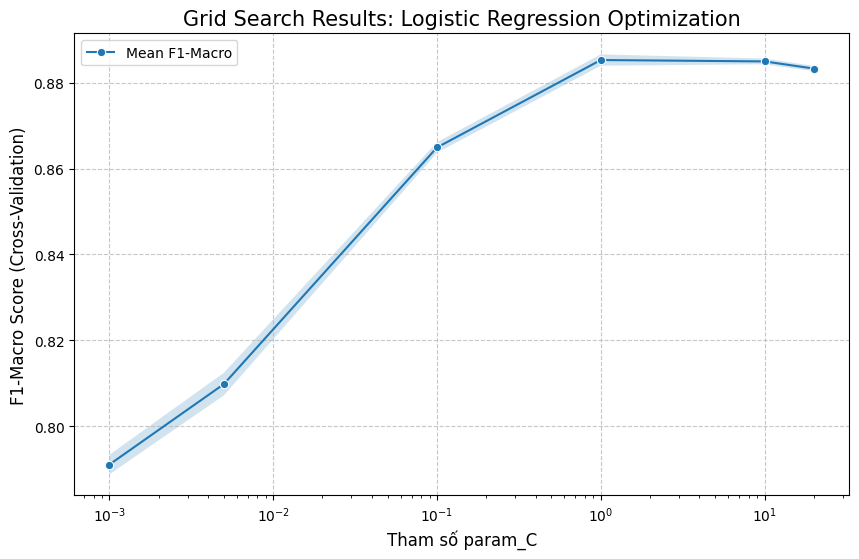

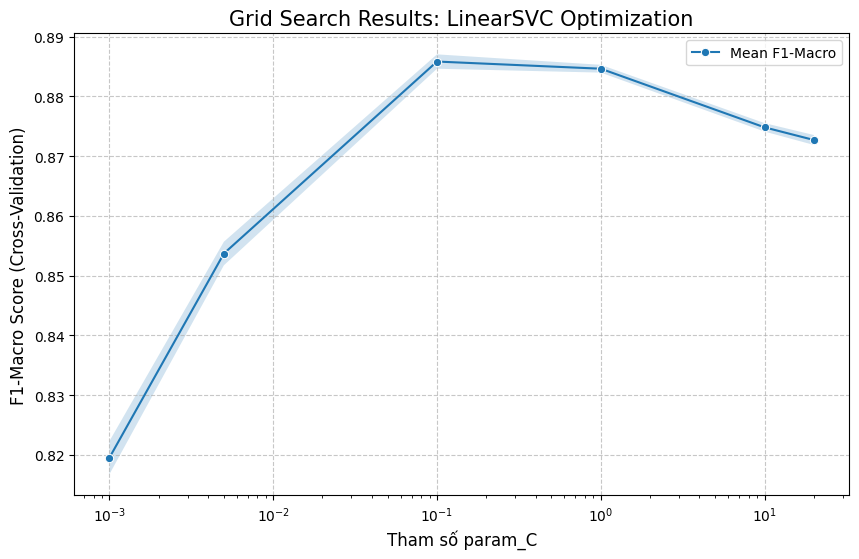

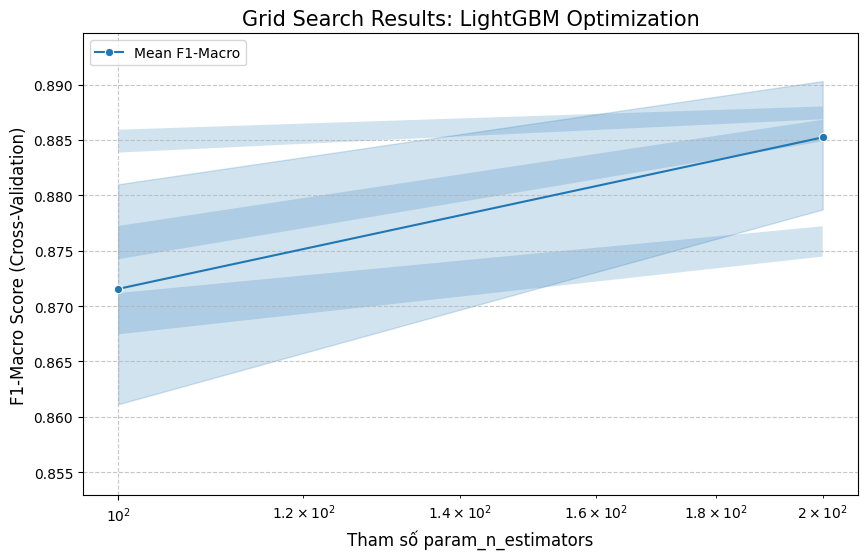

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_grid_search(grid_results, title, param_name='param_C'):

    results_df = pd.DataFrame(grid_results.cv_results_)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=results_df, x=param_name, y='mean_test_score', marker='o', label='Mean F1-Macro')
    plt.fill_between(results_df[param_name].astype(float),
                     results_df['mean_test_score'] - results_df['std_test_score'],
                     results_df['mean_test_score'] + results_df['std_test_score'],
                     alpha=0.2)

    plt.title(f'Grid Search Results: {title}', fontsize=15)
    plt.xlabel(f'Tham số {param_name}', fontsize=12)
    plt.ylabel('F1-Macro Score (Cross-Validation)', fontsize=12)

    plt.xscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

#vẽ đồ thị cho mô hình đã tinh chỉnh
plot_grid_search(grid_lr, "Logistic Regression Optimization")
plot_grid_search(grid_svc, "LinearSVC Optimization")
plot_grid_search(grid_lgbm, "LightGBM Optimization", param_name='param_n_estimators')

### Dùng clasifierVotting để cả 4 mô hình cùng đoán và đưa ra nhận xét

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier

# Xây dựng bộ Voting
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('svc', best_svc),
        ('nb', MultinomialNB()),
        ('lgbm', best_lgbm)
    ],
    voting='hard'
)

# Huấn luyện Ensemble
print(" Đang huấn luyện Ensemble Voting ")
ensemble_model.fit(X_train_vec, y_train)

--- Đang huấn luyện Ensemble Voting v3 (với LightGBM) ---
[LightGBM] [Info] Number of positive: 70055, number of negative: 66749
[LightGBM] [Info] Total Bins 1660007
[LightGBM] [Info] Number of data points in the train set: 136804, number of used features: 9975
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512083 -> initscore=0.048341
[LightGBM] [Info] Start training from score 0.048341


VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=1, class_weight='balanced',
                                                 max_iter=1000,
                                                 random_state=42)),
                             ('svc',
                              LinearSVC(C=0.1, class_weight='balanced',
                                        max_iter=2000, random_state=42)),
                             ('nb', MultinomialNB()),
                             ('lgbm',
                              LGBMClassifier(force_row_wise=True,
                                             n_estimators=200, n_jobs=-1,
                                             num_leaves=63, random_state=42))])

In [32]:
from sklearn.metrics import classification_report

y_val_pred = ensemble_model.predict(X_val_vec)

print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP VALIDATION")
print(classification_report(y_val, y_val_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


BÁO CÁO ĐÁNH GIÁ TRÊN TẬP VALIDATION
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      8344
           1       0.92      0.85      0.89      8757

    accuracy                           0.89     17101
   macro avg       0.89      0.89      0.89     17101
weighted avg       0.89      0.89      0.89     17101



In [33]:
# Dự đoán trên tập Test độc lập
y_test_pred = ensemble_model.predict(X_test_vec)

print("KẾT QUẢ CUỐI CÙNG (FINAL TEST SET)")
print(classification_report(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


KẾT QUẢ CUỐI CÙNG (FINAL TEST SET)
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      8344
           1       0.93      0.85      0.88      8757

    accuracy                           0.89     17101
   macro avg       0.89      0.89      0.89     17101
weighted avg       0.89      0.89      0.89     17101



In [36]:
import joblib

# 1. Lưu bộ Vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# 2. Lưu mô hình Ensemble
joblib.dump(ensemble_model, 'toxic_ensemble_model.pkl')



['toxic_ensemble_model.pkl']